## General stuff
Guassian:\
$\phi(x) = e^{-\|x\|^2}$

Image function:\
$ f : \mathbb{R}^2 \to \mathbb{R}$

Approximation:\
$ \hat{f}(x) = \sum^n_{i=0}\alpha_i (g_i \triangleright \phi)(y) = \sum^n_{i=0}\alpha_i (\psi(v_i) \triangleright \phi)(y)$

Lie group (dim 6):\
$G = \text{Aff}^+(2)$

Group action on $R^2$:\
For $g \in G, y \in R^2$ then $g \triangleright y = (x, A) \triangleright y := Ay + x$

For $f : \mathbb{R}^2 \to \mathbb{R}$ then $(g \triangleright f)(y) := f(g^{-1} \triangleright y)$ 

Parameter space (dim 6):\
$V = \mathbb{R}^2 \times \text{SO}(2) \times \text{SNM}(2)$

Mapping:\
$\psi : V \to G$\
$\psi(L, X, Y) = (L, \exp(X)\exp(Y))$

For $X = \begin{pmatrix}
0 & b \\
-b & 0
\end{pmatrix}$ then $\exp(X) = \begin{pmatrix}
\cos(b) & \sin(b) \\
-\sin(b) & \cos(b)
\end{pmatrix}$

For
$
Y=\begin{pmatrix}a & b \\ b & c\end{pmatrix},
$
define
$
m=\tfrac{a+c}{2}, \quad 
B = Y - mI = \begin{pmatrix}\tfrac{a-c}{2} & b \\[4pt] b & -\tfrac{a-c}{2}\end{pmatrix}, \quad 
s=\sqrt{b^{2}+\left(\tfrac{a-c}{2}\right)^{2}}.
$

Then
$
\exp(Y) \;=\; e^{\,m}\!\left( \cosh(s)\,I + \frac{\sinh(s)}{s}\,B \right).
$

Loss:\
$\mathcal{L} = \|f-\hat{f}\|_{L^2}$

In [63]:
import torch
import numpy as np
import math

In [64]:
# Group actions

def group_action(x: torch.Tensor, A: torch.Tensor, y: torch.Tensor) -> torch.Tensor:
    return torch.einsum('bjk,bk->bj', A, y) + x

def group_action_inv(x: torch.Tensor, A: torch.Tensor, y: torch.Tensor) -> torch.Tensor:
    return torch.einsum('bjk,bk->bj', torch.linalg.inv(A), y - x)

def group_action_func(x: torch.Tensor, A: torch.Tensor, y: torch.Tensor, f: callable) -> torch.Tensor:
    y_inv = group_action_inv(x, A, y)
    return f(y_inv)

In [72]:
# Mapping from parametric space to lie group

# Map exp of the theta of a 2x2 anti symmetric matrix to explicit
def exp_SO(theta: torch.Tensor) -> torch.Tensor:
    return torch.stack([torch.stack([torch.cos(theta), -torch.sin(theta)]),
                         torch.stack([torch.sin(theta), torch.cos(theta)])]).permute(2, 0, 1)

# Map exp of 2x2 symmetric matrix to explicit
def exp_SNM(A: torch.Tensor) -> torch.Tensor:
    a, b = A[..., 0, 0], A[..., 0, 1]
    c = A[..., 1, 1]

    m = 0.5 * (a + c)

    # Define B = A - mI
    B00 = 0.5 * (a - c)
    B01 = b
    B10 = b
    B11 = -0.5 * (a - c)

    # Compute s = sqrt(b^2 + ((a-c)/2)^2)
    eps = 1e-8 # counteract floating point inprecision
    s = torch.sqrt(b**2 + (0.5 * (a - c))**2)

    # Handle s=0 case with safe division
    sinhc = torch.where(s > 1e-12, torch.sinh(s) / s, torch.ones_like(s))

    # exp(A) = exp(m) * (cosh(s) * I + (sinh(s)/s) * B)
    expm = torch.zeros_like(A)
    expm[..., 0, 0] = torch.cosh(s) + sinhc * B00
    expm[..., 0, 1] = sinhc * B01
    expm[..., 1, 0] = sinhc * B10
    expm[..., 1, 1] = torch.cosh(s) + sinhc * B11

    return torch.exp(m)[..., None, None] * expm




In [66]:
# gaussian

def gaussian(y: torch.Tensor):
    norm = torch.linalg.vector_norm(y, dim=1)
    return torch.exp(-1 * torch.pow(norm, 2))

def f_hat(w: torch.Tensor, y: torch.Tensor) -> torch.Tensor:
    # calc all parameters
    alpha = w[0]
    a = w[1]
    b = w[2]
    c = w[3]
    theta = w[4]
    x1 = w[5]
    x2 = w[6]

    Y = torch.stack([torch.stack([a, b]), torch.stack([b, c])]).permute(2, 0, 1)

    A = torch.bmm(exp_SO(theta), exp_SNM(Y))
    x = torch.stack([x1, x2]).permute(1, 0)

    return torch.sigmoid(alpha * group_action_func(x, A, y, gaussian))


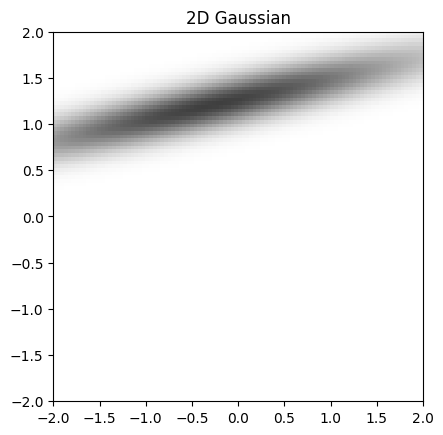

In [67]:

# plot 2D image of gaussian function

import matplotlib.pyplot as plt

# Create a grid of points
xv, yv = np.meshgrid(np.linspace(-2, 2, 100), np.linspace(-2, 2, 100))
points = np.stack([xv, yv], axis=-1)  # shape (100, 100, 2)

x = torch.tensor([-0.2805,1.2112])
# 1.1102,  0.7595, -0.3787, -1.3284,  0.3944, -0.2805,  1.2112

a = torch.tensor([0.7595])
b = torch.tensor([-0.3787])
c = torch.tensor([-1.3284])
theta = torch.tensor([0.3944])

Y = torch.tensor([[a, b], [b, c]], dtype=torch.float)

# Evaluate gaussian at each point
gauss_img = np.zeros((100, 100))
for i in range(100):
	for j in range(100):
		gauss_img[i, j] = torch.sigmoid(torch.tensor(1.1102))*group_action_func(x, exp_SO(theta) @ exp_SNM(Y), torch.tensor([points[i, j]], dtype=torch.float), gaussian)

plt.title("2D Gaussian")
plt.imshow(1 - gauss_img, extent=[-2, 2, -2, 2], origin='lower', cmap='gray', vmin=0, vmax=1)
plt.show()

In [78]:

torch.autograd.set_detect_anomaly(False)

# Training data: all black
input_x1 = torch.tensor([-2.0, 1.0, 0.0, 1.0, 2.0])
input_x2 = torch.tensor([-2.0, 1.0, 0.0, 1.0, 2.0])
# create a 4x4 tensor with all the same value a=0.3
a = 0.5
output_z = torch.full((5, 5), a)



learning_rate = 0.1
epochs = 50
batch = 5

# Prepare training data as a batch for vectorized computation
inputs = torch.stack([torch.tensor([i, j], dtype=torch.float) for i in range(-2, 3) for j in range(-2, 3)])  # shape (25, 2)
targets = torch.stack([output_z.flatten()]*batch)  # shape (25, )


w = torch.randn(7, batch, requires_grad=True)

first = True

for epoch in range(epochs):
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}/{epochs}")
        
    # Vectorized forward pass
    preds = torch.stack([
        f_hat(w, torch.stack([x] * batch)) for x in inputs
    ]).permute(1, 0) 

    eps = 1e-18 # counteract floating point inprecision
    loss = torch.sqrt(torch.sum((targets - preds), 0) ** 2 + eps).mean()
    loss.backward()
    with torch.no_grad():
        w -= learning_rate * w.grad
    w.grad.zero_()

preds = torch.stack([f_hat(w, torch.stack([x] * batch)) for x in inputs]).permute(1, 0)
loss = torch.sqrt(torch.sum((targets - preds), 1) ** 2)

print(loss)
# get index of minimum loss
min_index = torch.argmin(loss)
print(f"Minimum loss at index {min_index} with value {loss[min_index]}")
print(preds[min_index].reshape(5,5))
print(w[:,min_index])

Epoch 10/50
Epoch 20/50
Epoch 30/50
Epoch 40/50
Epoch 50/50
tensor([0.0088, 0.0979, 0.3054, 0.0362, 0.0282], grad_fn=<SqrtBackward0>)
Minimum loss at index 0 with value 0.008768916130065918
tensor([[0.5005, 0.5006, 0.5004, 0.5002, 0.5001],
        [0.5005, 0.5006, 0.5004, 0.5002, 0.5001],
        [0.5005, 0.5006, 0.5004, 0.5002, 0.5001],
        [0.5004, 0.5005, 0.5004, 0.5002, 0.5001],
        [0.5004, 0.5005, 0.5004, 0.5002, 0.5001]],
       grad_fn=<ReshapeAliasBackward0>)
tensor([ 2.2813e-03,  2.3158e+00, -5.7699e-01,  1.0175e+00,  3.7347e-01,
        -2.1537e+00, -1.0831e+00], grad_fn=<SelectBackward0>)


In [189]:
print(gaussian(torch.tensor([9.,5.])))

tensor(0.)


tensor([[ 2.2813e-03,  2.3158e+00, -5.7699e-01,  1.0175e+00,  3.7347e-01,
         -2.1537e+00, -1.0831e+00]], grad_fn=<StackBackward0>)


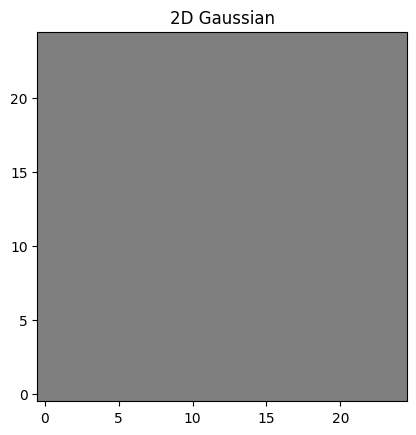

In [79]:
# plot 2D image of gaussian function

import matplotlib.pyplot as plt
resolution = 25

# Create a grid of points
xv, yv = np.meshgrid(np.linspace(-2, 2, resolution), np.linspace(-2, 2, resolution))
points = torch.tensor(np.stack([xv, yv], axis=-1), dtype=torch.float)  # shape (100, 100, 2)

print(torch.stack([w[:,min_index]]))
# Evaluate gaussian at each point
gauss_img = np.zeros((resolution, resolution))
for i in range(0, resolution):
	for j in range(0, resolution):
		gauss_img[i, j] = f_hat(w[:,min_index].unsqueeze(1), torch.stack([points[i, j]]))

plt.title("2D Gaussian")
plt.imshow(1 - gauss_img, origin='lower', cmap='gray', vmin=0, vmax=1)
plt.show()

tensor([0.8576, 0.8576, 0.8576])
